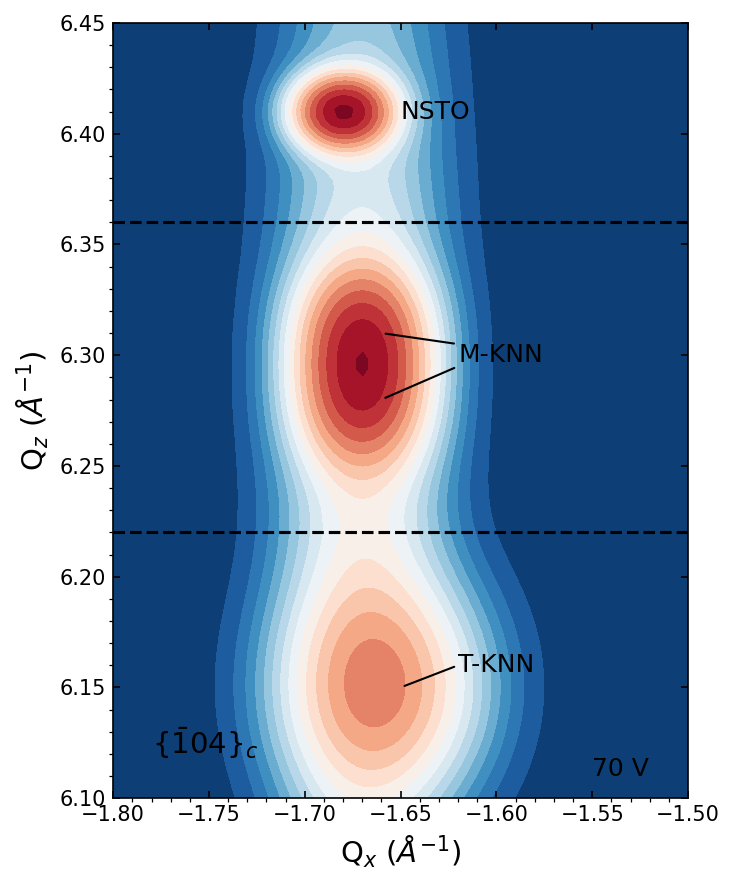

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Axes
qx = np.linspace(-1.8, -1.5, 100)
qz = np.linspace(6.1, 6.45, 100)
X, Z = np.meshgrid(qx, qz)

def gaussian_2d(x, z, x0, z0, sx, sz, A):
    return A * np.exp(-((x - x0)**2)/(2*sx**2) - ((z - z0)**2)/(2*sz**2))

# NSTO (Top, Sharp)
peak_nsto = gaussian_2d(X, Z, -1.68, 6.41, 0.015, 0.01, 1000)

# M-KNN (Middle, Two lobes)
peak_m1 = gaussian_2d(X, Z, -1.67, 6.31, 0.02, 0.02, 600)
peak_m2 = gaussian_2d(X, Z, -1.67, 6.28, 0.02, 0.02, 550)

# T-KNN (Bottom, Broad)
peak_t = gaussian_2d(X, Z, -1.66, 6.15, 0.03, 0.03, 400)

# Background streak (Tail)
streak = gaussian_2d(X, Z, -1.67, 6.25, 0.025, 0.15, 200)

# Total Intensity
intensity = peak_nsto + peak_m1 + peak_m2 + peak_t + streak + 50
log_int = np.log10(intensity)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(5, 6), dpi=150)

# Contourf
# Blue-White-Red
cmap = plt.cm.RdBu_r
cf = ax.contourf(X, Z, log_int, levels=20, cmap=cmap)

# Dashed lines
ax.axhline(6.36, color='black', linestyle='--')
ax.axhline(6.22, color='black', linestyle='--')

# Labels
ax.text(-1.65, 6.41, 'NSTO', fontsize=12, va='center')
ax.text(-1.62, 6.3, 'M-KNN', fontsize=12, va='center')
ax.annotate('', xy=(-1.66, 6.31), xytext=(-1.62, 6.305), arrowprops=dict(arrowstyle='-'))
ax.annotate('', xy=(-1.66, 6.28), xytext=(-1.62, 6.295), arrowprops=dict(arrowstyle='-'))

ax.text(-1.62, 6.16, 'T-KNN', fontsize=12, va='center')
ax.annotate('', xy=(-1.65, 6.15), xytext=(-1.62, 6.16), arrowprops=dict(arrowstyle='-'))

ax.text(-1.78, 6.12, r'$\{\bar{1}04\}_c$', fontsize=14)
ax.text(-1.55, 6.11, '70 V', fontsize=12)

# Styling
ax.set_xlabel(r'Q$_x$ ($\AA^{-1}$)', fontsize=14)
ax.set_ylabel(r'Q$_z$ ($\AA^{-1}$)', fontsize=14)
ax.set_xlim(-1.8, -1.5)
ax.set_ylim(6.1, 6.45)

# Ticks
ax.minorticks_on()
ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()
